5. ViT Inference and Fine‑Tuning vs. CNN on Small Datasets

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import timm
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [ ]:
# Load CIFAR-10 Dataset (The "Small Dataset")
# ViT requires resizing to 224x224 (Standard ImageNet resolution)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# CNN works natively on 32x32
transform_cnn = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

print("Loading CIFAR-10 Test Set...")
testset_vit = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_vit)
loader_vit = torch.utils.data.DataLoader(testset_vit, batch_size=32, shuffle=False)

testset_cnn = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cnn)
loader_cnn = torch.utils.data.DataLoader(testset_cnn, batch_size=32, shuffle=False)

In [ ]:
# Load Models
# ViT: Pre-trained on ImageNet-21k, Fine-tuned on CIFAR-10
vit_model = timm.create_model("vit_base_patch16_224", pretrained=True, num_classes=10).to(device)
vit_model.eval()

# CNN: ResNet-20 trained on CIFAR-10
cnn_model = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True).to(device)
cnn_model.eval()

In [4]:
# Inference Function
def run_inference(model, loader, name):
    preds, targets = [], []
    start = time.time()

    with torch.no_grad():
        for i, (images, labels) in enumerate(loader):
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            targets.extend(labels.numpy())

            if i >= 10: break # Limit to 10 batches for quick demo

    total_time = (time.time() - start) * 1000 # ms
    acc = accuracy_score(targets, preds) * 100
    print(f"{name} Results: Accuracy = {acc:.2f}% | Time = {total_time:.1f}ms")
    return preds, targets

In [5]:
# Execute
print("\nComparison")
vit_preds, vit_true = run_inference(vit_model, loader_vit, "ViT")
cnn_preds, cnn_true = run_inference(cnn_model, loader_cnn, "CNN")


Comparison
ViT Results: Accuracy = 10.23% | Time = 4990.0ms
CNN Results: Accuracy = 80.68% | Time = 304.2ms


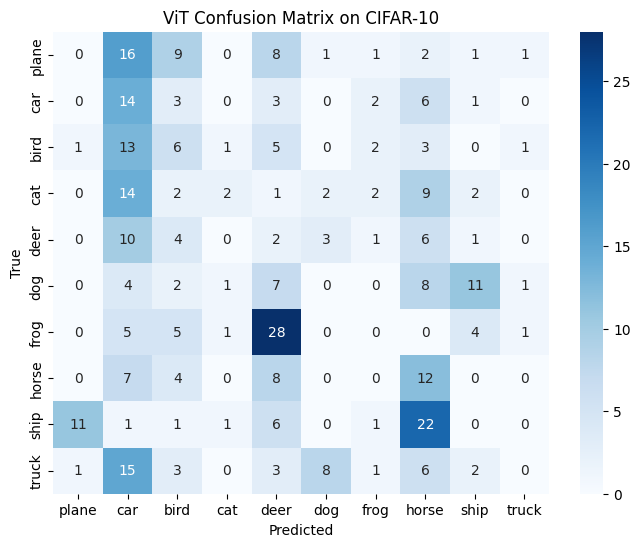

In [6]:
# Generate Plots (Confusion Matrix)
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
cm = confusion_matrix(vit_true, vit_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("ViT Confusion Matrix on CIFAR-10")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

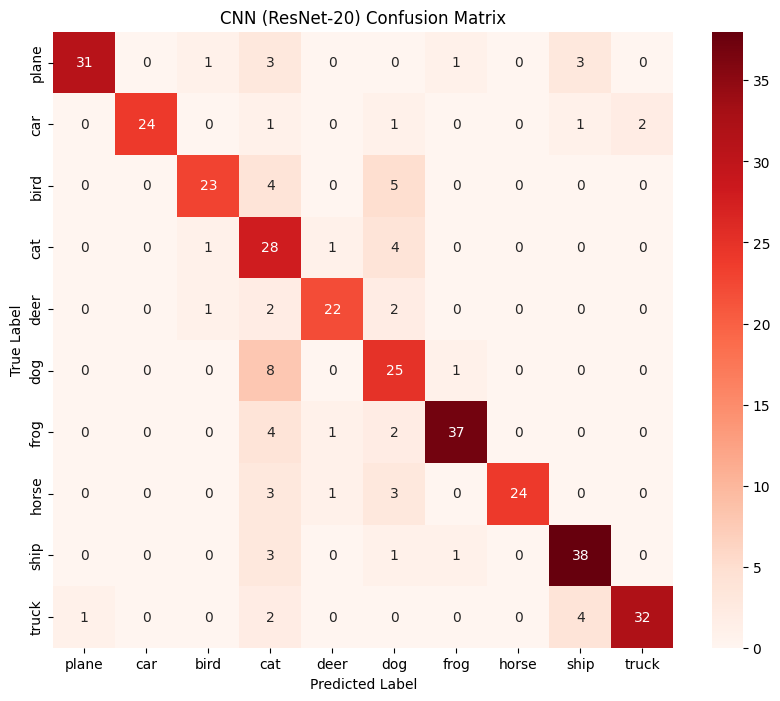

In [7]:

# CNN Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(cnn_true, cnn_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title("CNN (ResNet-20) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Predictions


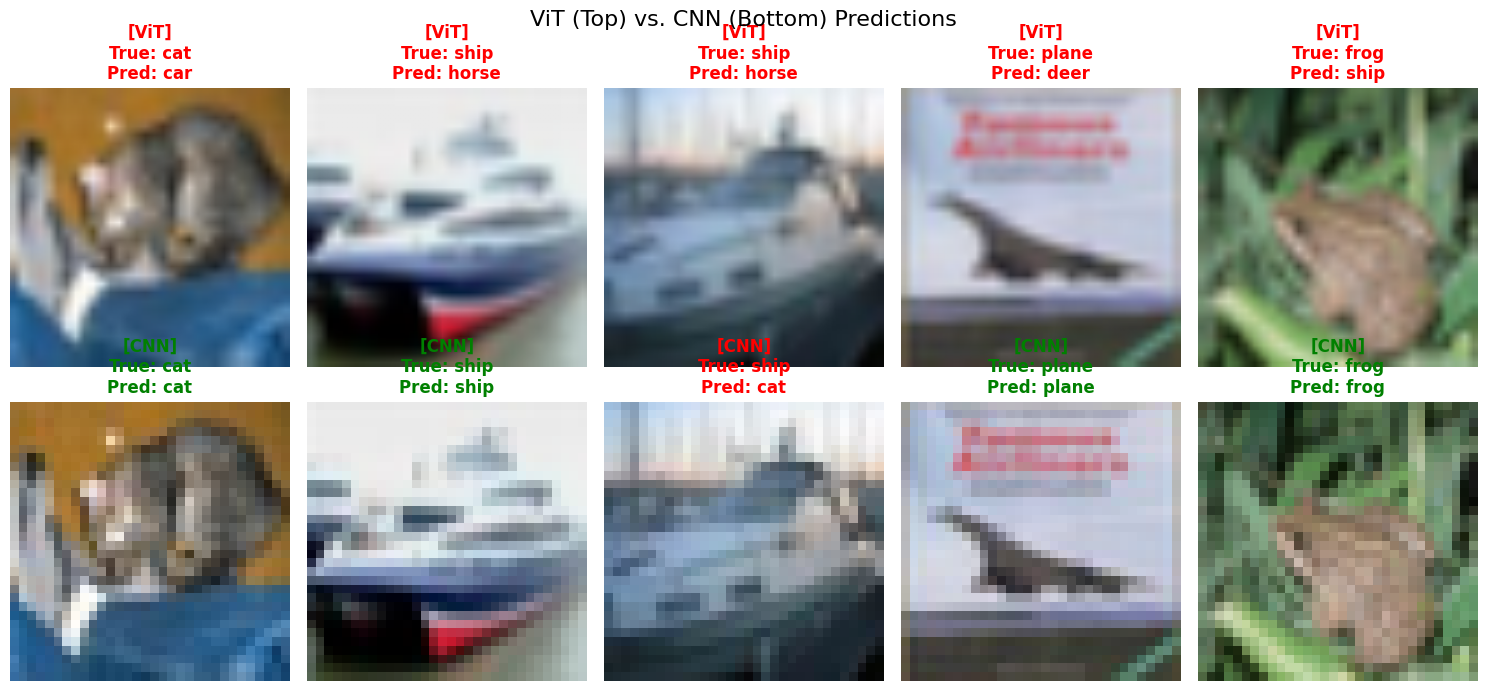

In [8]:
# Get Predictions for the First 5 Images
dataiter_vit = iter(loader_vit)
images_vit, labels = next(dataiter_vit)
images_vit = images_vit.to(device)

dataiter_cnn = iter(loader_cnn)
images_cnn, _ = next(dataiter_cnn) # Labels are same as above
images_cnn = images_cnn.to(device)

# Run Inference
with torch.no_grad():
    # ViT Prediction
    out_vit = vit_model(images_vit)
    _, preds_vit = torch.max(out_vit, 1)

    # CNN Prediction
    out_cnn = cnn_model(images_cnn)
    _, preds_cnn = torch.max(out_cnn, 1)

# Visualization
def imshow(img, ax):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    ax.imshow(np.transpose(npimg, (1, 2, 0)))
    ax.axis('off')

print("\nPredictions")
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("ViT (Top) vs. CNN (Bottom) Predictions", fontsize=16)

# Move images back to CPU for plotting
images_vit = images_vit.cpu()
images_cnn = images_cnn.cpu()

for i in range(5):
    # Top Row: ViT Results
    ax_vit = axes[0, i]
    imshow(images_vit[i], ax_vit)

    true_label = classes[labels[i]]
    vit_pred = classes[preds_vit[i]]

    # Green if correct, Red if wrong
    color = 'green' if vit_pred == true_label else 'red'
    ax_vit.set_title(f"[ViT]\nTrue: {true_label}\nPred: {vit_pred}", color=color, fontweight='bold')

    # Bottom Row: CNN Results
    ax_cnn = axes[1, i]
    imshow(images_cnn[i], ax_cnn)

    cnn_pred = classes[preds_cnn[i]]
    color = 'green' if cnn_pred == true_label else 'red'
    ax_cnn.set_title(f"[CNN]\nTrue: {true_label}\nPred: {cnn_pred}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()

# Fine-Tuning ViT

In [9]:
from tensorflow import keras

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalize to [0,1]
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape : (10000, 32, 32, 3)


In [ ]:
from keras_hub.models import Backbone
import tensorflow as tf
from tensorflow import keras

# Load ViT backbone
vit_backbone = Backbone.from_preset("vit_base_patch16_224_imagenet")

# Freeze the ViT backbone
vit_backbone.trainable = False

# Build model
vit_model = keras.Sequential([
    keras.layers.Resizing(224, 224),
    vit_backbone,
    keras.layers.GlobalAveragePooling1D(),
    keras.layers.Dense(10, activation="softmax")
])

# Compile
vit_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Train only the classifier head
history = vit_model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=5,
    batch_size=64
)


In [12]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


ViT (Keras, frozen backbone) Test Accuracy: 94.16%
Test Loss: 0.1750
157/157 ━━━━━━━━━━━━━━━━━━━━ 117s 726ms/step


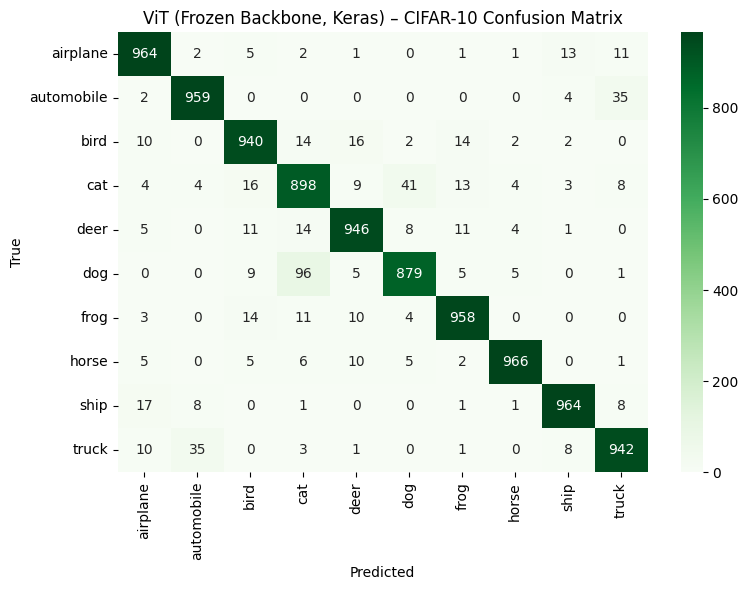


Classification Report:
              precision    recall  f1-score   support

    airplane       0.95      0.96      0.95      1000
  automobile       0.95      0.96      0.96      1000
        bird       0.94      0.94      0.94      1000
         cat       0.86      0.90      0.88      1000
        deer       0.95      0.95      0.95      1000
         dog       0.94      0.88      0.91      1000
        frog       0.95      0.96      0.96      1000
       horse       0.98      0.97      0.97      1000
        ship       0.97      0.96      0.97      1000
       truck       0.94      0.94      0.94      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [13]:
# CIFAR-10 class names
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

#Evaluate on test set
test_loss, test_acc = vit_model.evaluate(x_test, y_test, verbose=0)
print(f"\nViT (Keras, frozen backbone) Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

#Get predictions
y_prob = vit_model.predict(x_test, batch_size=64)       # shape: (10000, 10)
y_pred = np.argmax(y_prob, axis=1)                     # predicted class indices
y_true = y_test.flatten()                              # true labels (N,1) -> (N,)

#Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("ViT (Frozen Backbone, Keras) – CIFAR-10 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# Text report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))
